# PM2.5 Air Pollution - Exploratory Data Analysis

This notebook performs comprehensive exploratory data analysis on the PM2.5 air pollution dataset.

In [32]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import sys

# Add src directory to path
sys.path.append('../src')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

## 1. Data Loading and Initial Inspection

In [33]:
# Load data using our data loading module

# Use existing imports from earlier cells if available; fallback only if needed
try:
    Path
    sys
except NameError:
    from pathlib import Path
    import sys

# Make sure Python can find the module from common project locations
candidate_src_paths = [
    Path("C:/Users/91860/Desktop/AeroGraphFed/src"),
    Path.cwd() / "src",
    Path.cwd().parent / "src",
]

for src_path in candidate_src_paths:
    if src_path.exists() and str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

# Import module with package import first, then file-based fallback
import importlib
import importlib.util

module = None
checked_modules = []
for module_name in ("load_data", "src.load_data", "data.load_data"):
    checked_modules.append(module_name)
    try:
        module = importlib.import_module(module_name)
        break
    except ModuleNotFoundError:
        continue

# Fallback: load directly from potential file locations
if module is None:
    checked_files = []
    for src_path in candidate_src_paths:
        for file_path in (
            src_path / "load_data.py",
            src_path / "data" / "load_data.py",
            src_path.parent / "src" / "load_data.py",
        ):
            checked_files.append(str(file_path))
            if file_path.exists():
                spec = importlib.util.spec_from_file_location("load_data", file_path)
                if spec is not None and spec.loader is not None:
                    module = importlib.util.module_from_spec(spec)
                    spec.loader.exec_module(module)
                    print(f"✅ Loaded module from file: {file_path}")
                    break
        if module is not None:
            break

if module is None:
    print(
        "⚠️ Could not import load_data module. "
        "Falling back to pandas-based loader.\n"
        f"Checked modules: {checked_modules}\n"
        f"Checked files: {checked_files}"
    )

    def load_dataset(path):
        return pd.read_csv(path)

    def inspect_dataset(dataframe):
        return {
            "shape": dataframe.shape,
            "columns": list(dataframe.columns),
            "dtypes": dataframe.dtypes.astype(str).to_dict(),
            "missing_values": dataframe.isnull().sum().to_dict(),
        }

    def print_dataset_info(info):
        print(f"Shape: {info['shape']}")
        print(f"Columns ({len(info['columns'])}): {info['columns']}")
else:
    load_dataset = getattr(module, "load_dataset", lambda path: pd.read_csv(path))
    inspect_dataset = getattr(
        module,
        "inspect_dataset",
        lambda dataframe: {
            "shape": dataframe.shape,
            "columns": list(dataframe.columns),
            "dtypes": dataframe.dtypes.astype(str).to_dict(),
            "missing_values": dataframe.isnull().sum().to_dict(),
        },
    )
    print_dataset_info = getattr(
        module,
        "print_dataset_info",
        lambda info: print(f"Shape: {info['shape']}, Columns: {len(info['columns'])}"),
    )

# Load the dataset
data_path_candidates = [
    Path("C:/Users/91860/Desktop/AeroGraphFed/data/raw/global_data.csv"),
    Path.cwd() / "data" / "raw" / "global_data.csv",
    Path.cwd().parent / "data" / "raw" / "global_data.csv",
]

df = None
last_error = None

for data_path in data_path_candidates:
    try:
        if data_path.exists():
            df = load_dataset(str(data_path))
            print(f"✅ Dataset loaded successfully from: {data_path}")
            info = inspect_dataset(df)
            print_dataset_info(info)
            break
    except Exception as e:
        last_error = e

if df is None:
    print("❌ Could not load dataset from any known path")
    if last_error is not None:
        print(f"Last error: {last_error}")

⚠️ Could not import load_data module. Falling back to pandas-based loader.
Checked modules: ['load_data', 'src.load_data', 'data.load_data']
Checked files: ['C:\\Users\\91860\\Desktop\\AeroGraphFed\\src\\load_data.py', 'C:\\Users\\91860\\Desktop\\AeroGraphFed\\src\\data\\load_data.py', 'C:\\Users\\91860\\Desktop\\AeroGraphFed\\src\\load_data.py', 'c:\\Users\\91860\\Desktop\\AeroGraphFed\\notebook\\src\\load_data.py', 'c:\\Users\\91860\\Desktop\\AeroGraphFed\\notebook\\src\\data\\load_data.py', 'c:\\Users\\91860\\Desktop\\AeroGraphFed\\notebook\\src\\load_data.py', 'c:\\Users\\91860\\Desktop\\AeroGraphFed\\src\\load_data.py', 'c:\\Users\\91860\\Desktop\\AeroGraphFed\\src\\data\\load_data.py', 'c:\\Users\\91860\\Desktop\\AeroGraphFed\\src\\load_data.py']
✅ Dataset loaded successfully from: C:\Users\91860\Desktop\AeroGraphFed\data\raw\global_data.csv
Shape: (6396, 18)
Columns (18): ['Region', 'Year', 'Population-Weighted PM2.5 [ug/m3]', 'Geographic-Mean PM2.5 [ug/m3]', 'Population Coverag

## 2. Dataset Shape and Basic Statistics

In [34]:
print(f"Dataset Shape: {df.shape}")
print(f"\nDataset Info:")
df.info()

Dataset Shape: (6396, 18)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6396 entries, 0 to 6395
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Region                             6396 non-null   object 
 1   Year                               6396 non-null   int64  
 2   Population-Weighted PM2.5 [ug/m3]  6396 non-null   float64
 3   Geographic-Mean PM2.5 [ug/m3]      6396 non-null   float64
 4   Population Coverage [%]            6396 non-null   float64
 5   Geographic Coverage [%]            6396 non-null   float64
 6   Total Population [million people]  6396 non-null   float64
 7   % pop >= 5 ug/m3 [%]               6396 non-null   float64
 8   % pop >= 10 ug/m3 [%]              6396 non-null   float64
 9   % pop >= 15 ug/m3 [%]              6396 non-null   float64
 10  % pop >= 25 ug/m3 [%]              6396 non-null   float64
 11  % pop >= 30 ug/

In [35]:
# Display basic statistics
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Year,Population-Weighted PM2.5 [ug/m3],Geographic-Mean PM2.5 [ug/m3],Population Coverage [%],Geographic Coverage [%],Total Population [million people],% pop >= 5 ug/m3 [%],% pop >= 10 ug/m3 [%],% pop >= 15 ug/m3 [%],% pop >= 25 ug/m3 [%],% pop >= 30 ug/m3 [%],% pop >= 35 ug/m3 [%],% pop >= 40 ug/m3 [%],% pop >= 45 ug/m3 [%],% pop >= 50 ug/m3 [%],% pop >= 55 ug/m3 [%],% pop >= 60 ug/m3 [%]
count,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000
mean,2010.500000,19.820935,19.304112,99.583865,98.200000,28.159379,90.240072,74.913493,54.480128,26.275016,18.712320,13.106379,9.035944,6.203299,4.440041,3.269168,2.452611
std,7.500586,13.671305,13.518857,2.717133,8.252218,120.336058,28.079741,40.479653,45.032833,37.937546,33.305534,28.055674,23.076012,19.048160,15.961003,13.296194,11.130365
min,1998.000000,1.300000,1.000000,68.200000,1.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2004.000000,10.300000,9.800000,99.900000,99.200000,0.220000,100.000000,62.925000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2010.500000,16.700000,16.300000,100.000000,99.800000,4.201000,100.000000,100.000000,72.350000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2017.000000,25.900000,24.900000,100.000000,100.000000,17.102250,100.000000,100.000000,100.000000,53.025000,21.025000,3.900000,0.300000,0.000000,0.000000,0.000000,0.000000
max,2023.000000,98.400000,97.900000,100.000000,100.000000,1398.520000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


## 3. Missing Values Analysis

In [36]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Create missing values dataframe
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
}).sort_values('Missing Values', ascending=False)

missing_only_df = missing_df[missing_df['Missing Values'] > 0]

print("Missing Values Summary:")

if missing_only_df.empty:
    print("No missing values found in the dataset.")
else:
    # Plot missing values
    plt.figure(figsize=(12, 6))
    missing_only_df['Missing Values'].plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(missing_only_df)

Missing Values Summary:
No missing values found in the dataset.


## 4. PM2.5 Distribution Analysis

In [ ]:
# Identify PM2.5 columns
pm25_cols = [col for col in df.columns if 'PM2.5' in col]
print(f"PM2.5 related columns: {pm25_cols}")

# Focus on Population-Weighted PM2.5
target_col = 'Population-Weighted PM2.5 [ug/m3]'

# Create distribution plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0, 0].hist(df[target_col], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Population-Weighted PM2.5')
axes[0, 0].set_xlabel('PM2.5 (μg/m³)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(df[target_col])
axes[0, 1].set_title('Box Plot of PM2.5 Values')
axes[0, 1].set_ylabel('PM2.5 (μg/m³)')
axes[0, 1].grid(True, alpha=0.3)

# Density plot
df[target_col].plot(kind='density', ax=axes[1, 0], color='red')
axes[1, 0].set_title('Density Plot of PM2.5 Values')
axes[1, 0].set_xlabel('PM2.5 (μg/m³)')
axes[1, 0].grid(True, alpha=0.3)

# Violin plot
sns.violinplot(y=df[target_col], ax=axes[1, 1])
axes[1, 1].set_title('Violin Plot of PM2.5 Values')
axes[1, 1].set_ylabel('PM2.5 (μg/m³)')

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nPM2.5 Statistics:")
print(f"Mean: {df[target_col].mean():.2f} μg/m³")
print(f"Median: {df[target_col].median():.2f} μg/m³")
print(f"Std Dev: {df[target_col].std():.2f} μg/m³")
print(f"Min: {df[target_col].min():.2f} μg/m³")
print(f"Max: {df[target_col].max():.2f} μg/m³")
print(f"25th Percentile: {df[target_col].quantile(0.25):.2f} μg/m³")
print(f"75th Percentile: {df[target_col].quantile(0.75):.2f} μg/m³")

PM2.5 related columns: ['Population-Weighted PM2.5 [ug/m3]', 'Geographic-Mean PM2.5 [ug/m3]']


## 5. PM2.5 Trend Over Years

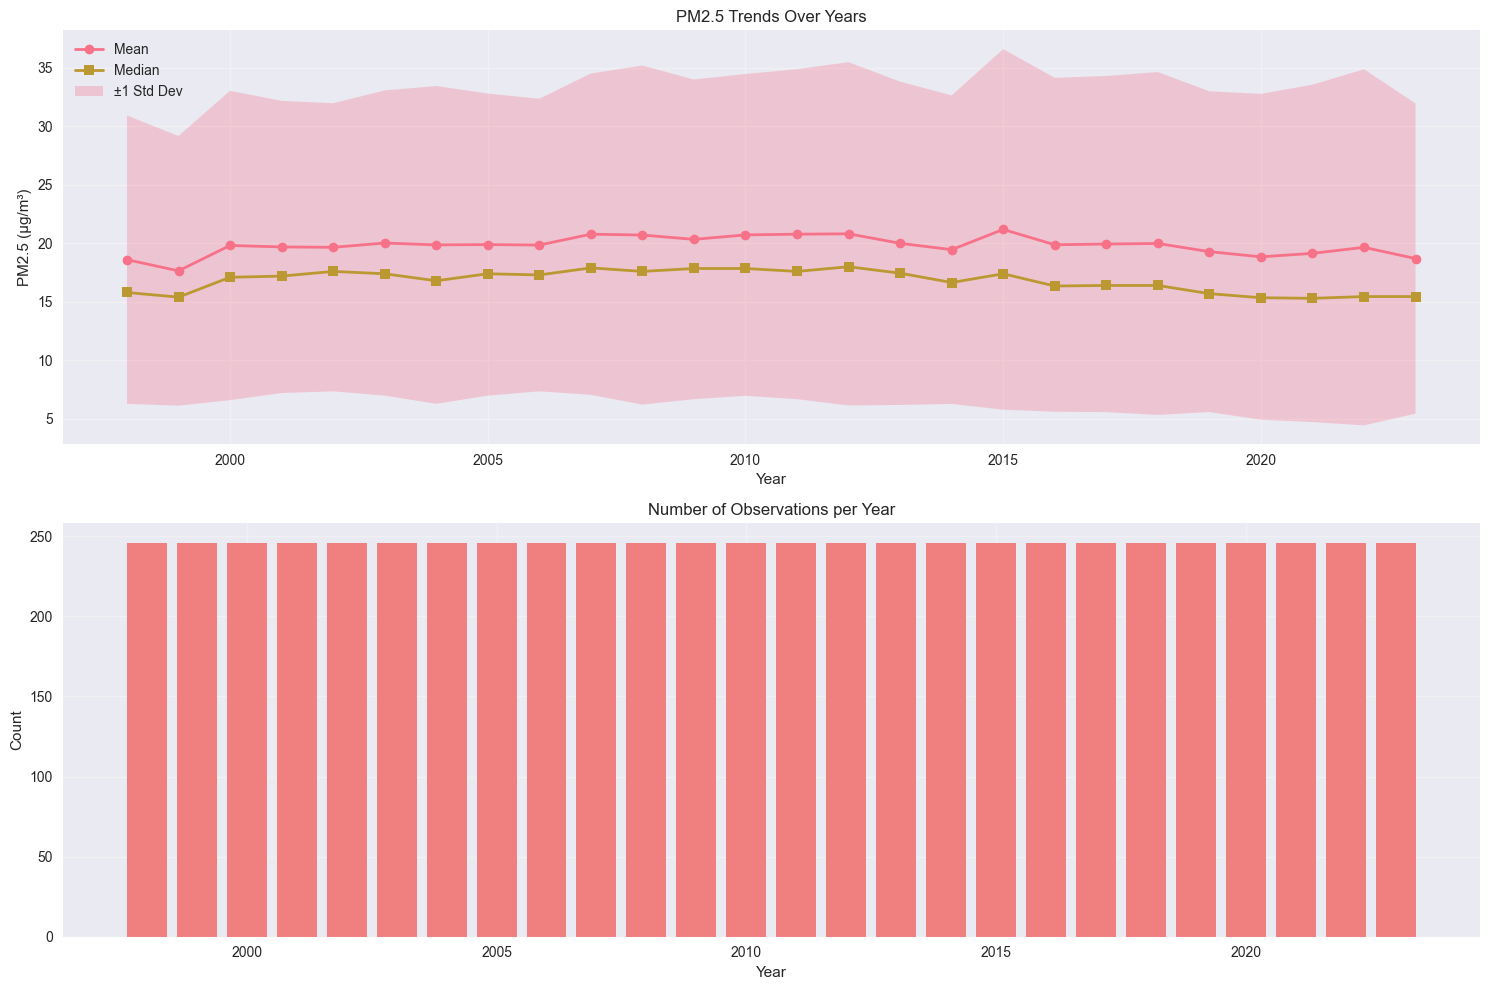

Yearly PM2.5 Statistics:


,Year,mean,median,std,count
0,1998,18.60,15.80,12.33,246
1,1999,17.65,15.40,11.53,246
2,2000,19.82,17.10,13.23,246
3,2001,19.69,17.20,12.50,246
4,2002,19.66,17.60,12.32,246
5,2003,20.03,17.40,13.05,246
6,2004,19.87,16.80,13.59,246
7,2005,19.89,17.40,12.92,246
8,2006,19.85,17.30,12.51,246
9,2007,20.78,17.90,13.74,246


In [ ]:
# Analyze PM2.5 trends over years
yearly_pm25 = df.groupby('Year')[target_col].agg(['mean', 'median', 'std', 'count']).reset_index()

# Plot trends
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Mean PM2.5 over years
axes[0].plot(yearly_pm25['Year'], yearly_pm25['mean'], marker='o', linewidth=2, label='Mean')
axes[0].plot(yearly_pm25['Year'], yearly_pm25['median'], marker='s', linewidth=2, label='Median')
axes[0].fill_between(yearly_pm25['Year'], 
                    yearly_pm25['mean'] - yearly_pm25['std'],
                    yearly_pm25['mean'] + yearly_pm25['std'],
                    alpha=0.3, label='±1 Std Dev')
axes[0].set_title('PM2.5 Trends Over Years')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Number of observations per year
axes[1].bar(yearly_pm25['Year'], yearly_pm25['count'], color='lightcoral')
axes[1].set_title('Number of Observations per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display yearly statistics
print("Yearly PM2.5 Statistics:")
display(yearly_pm25.round(2))

## 6. Top Polluted Regions Analysis

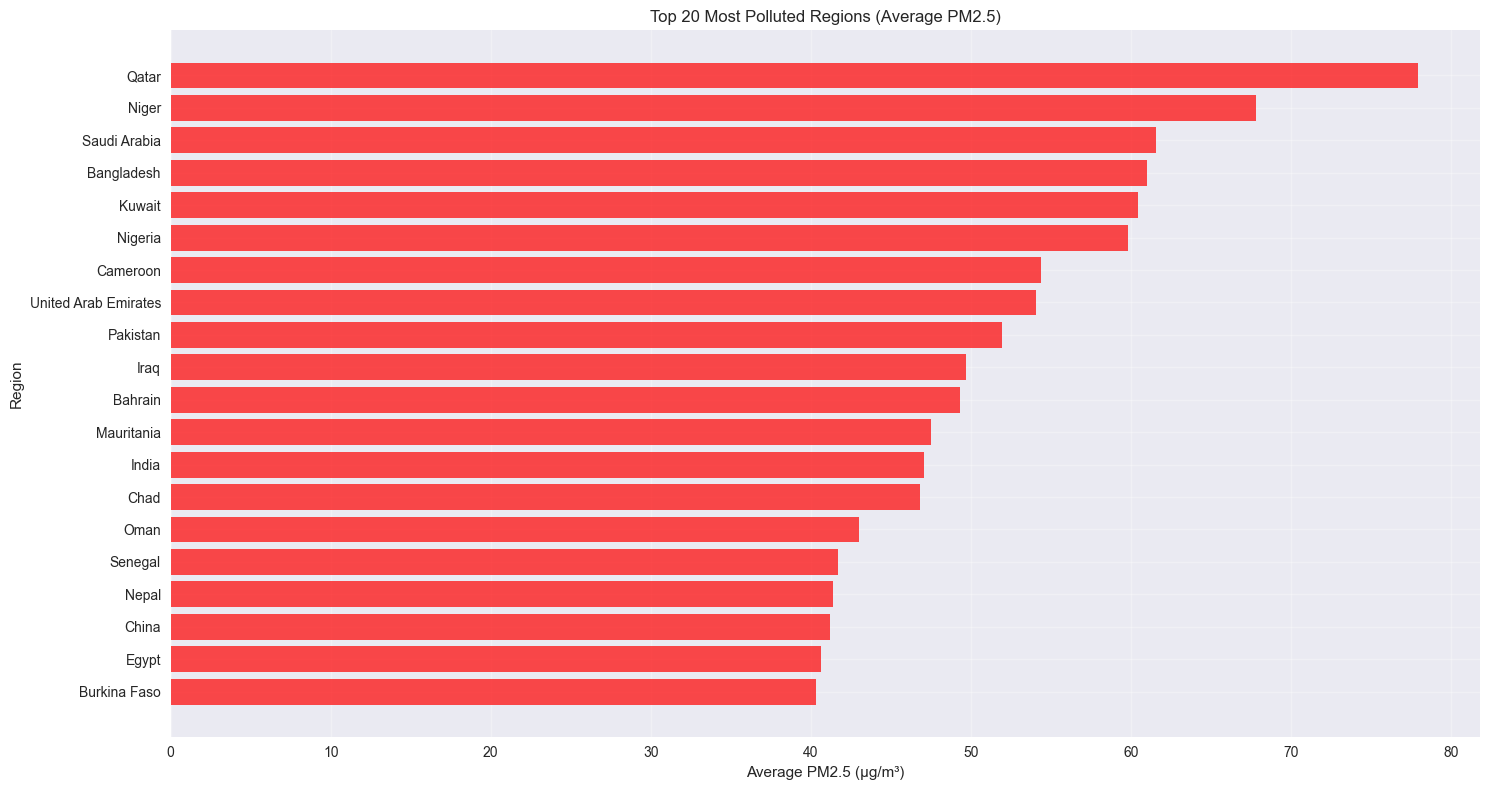

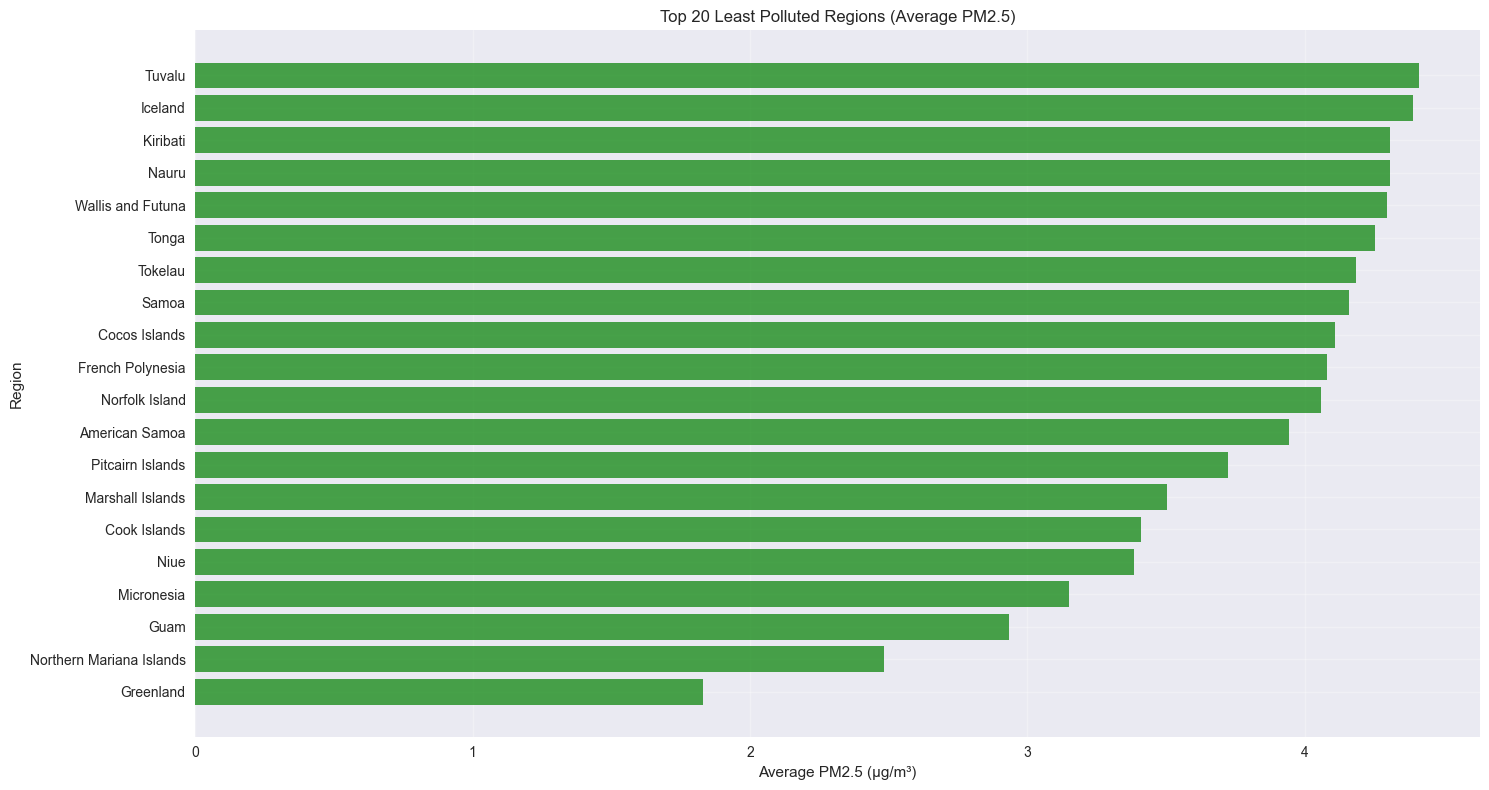

Top 10 Most Polluted Regions:


,Region,mean,median,std,count
177,Qatar,77.92,77.65,8.35,26
155,Niger,67.81,67.30,7.51,26
192,Saudi Arabia,61.55,63.15,7.21,26
18,Bangladesh,60.98,63.10,9.23,26
114,Kuwait,60.45,60.70,6.73,26
156,Nigeria,59.83,60.05,6.09,26
37,Cameroon,54.35,53.95,3.26,26
231,United Arab Emirates,54.07,54.50,4.08,26
164,Pakistan,51.96,52.55,4.46,26
101,Iraq,49.70,49.25,5.85,26


In [ ]:
# Analyze top polluted regions
region_pm25 = df.groupby('Region')[target_col].agg(['mean', 'median', 'std', 'count']).reset_index()
region_pm25 = region_pm25[region_pm25['count'] > 5]  # Filter regions with sufficient data
region_pm25 = region_pm25.sort_values('mean', ascending=False)

# Top 20 most polluted regions
top_20_regions = region_pm25.head(20)

# Plot top polluted regions
plt.figure(figsize=(15, 8))
plt.barh(top_20_regions['Region'][::-1], top_20_regions['mean'][::-1], color='red', alpha=0.7)
plt.title('Top 20 Most Polluted Regions (Average PM2.5)')
plt.xlabel('Average PM2.5 (μg/m³)')
plt.ylabel('Region')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Bottom 20 least polluted regions
bottom_20_regions = region_pm25.tail(20)

plt.figure(figsize=(15, 8))
plt.barh(bottom_20_regions['Region'][::-1], bottom_20_regions['mean'][::-1], color='green', alpha=0.7)
plt.title('Top 20 Least Polluted Regions (Average PM2.5)')
plt.xlabel('Average PM2.5 (μg/m³)')
plt.ylabel('Region')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10 Most Polluted Regions:")
display(top_20_regions.head(10).round(2))

## 7. Geographic Distribution Analysis

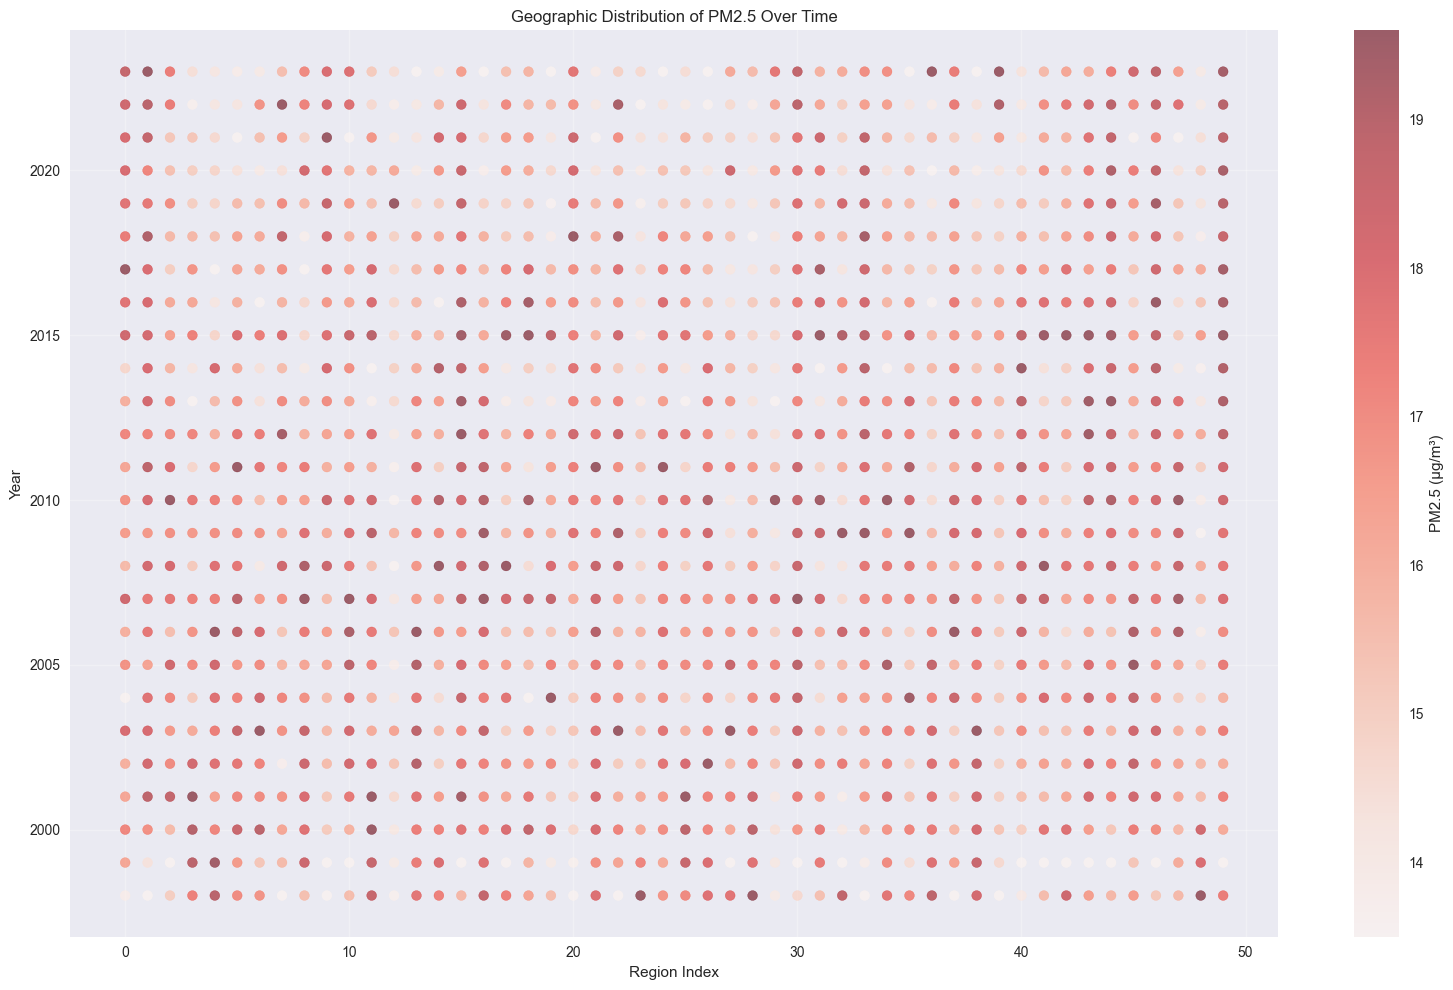

In [ ]:
# Create a geographic scatter plot (simulated since we don't have lat/lon)
# We'll use region indices as proxy coordinates
unique_regions = df['Region'].unique()
region_to_idx = {region: i for i, region in enumerate(unique_regions)}

# Create a scatter plot of PM2.5 values by region
plt.figure(figsize=(16, 10))

# Create scatter plot with regions colored by PM2.5 levels
for region in unique_regions[:50]:  # Limit to first 50 regions for visibility
    region_data = df[df['Region'] == region]
    if len(region_data) > 0:
        x_coords = [region_to_idx[region]] * len(region_data)
        y_coords = region_data['Year']
        colors = region_data[target_col]
        
        scatter = plt.scatter(x_coords, y_coords, c=colors, s=50, alpha=0.6, cmap='Reds')

plt.colorbar(scatter, label='PM2.5 (μg/m³)')
plt.title('Geographic Distribution of PM2.5 Over Time')
plt.xlabel('Region Index')
plt.ylabel('Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

Numeric columns: 17


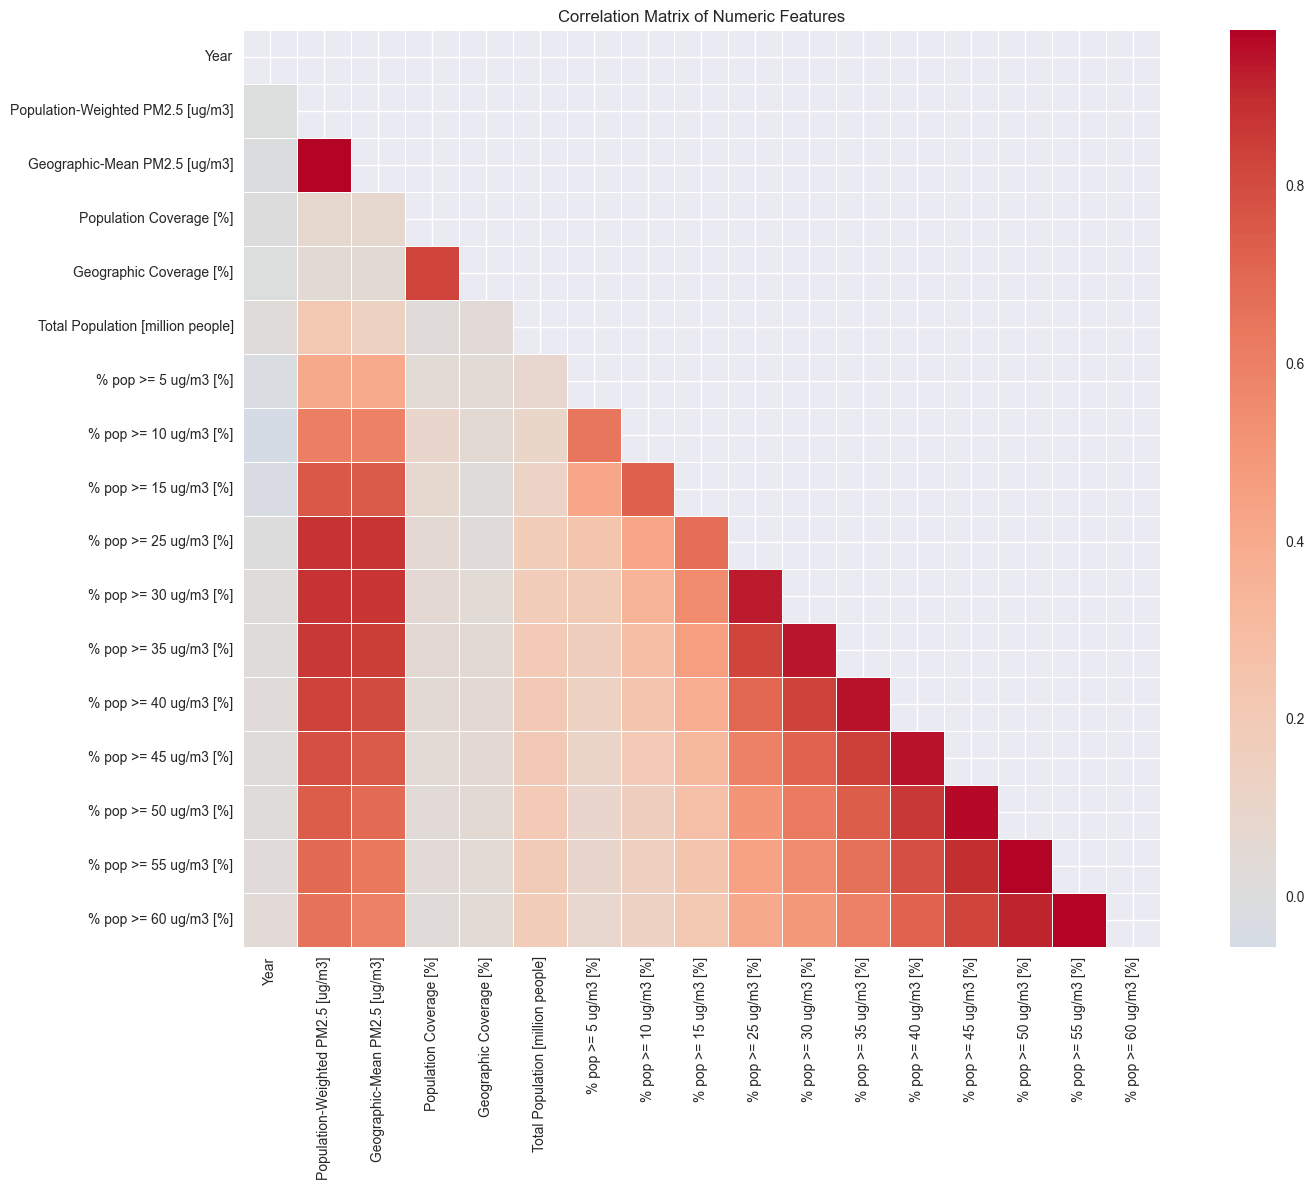


Correlations with Population-Weighted PM2.5 [ug/m3]:


Population-Weighted PM2.5 [ug/m3]    1.000000
Geographic-Mean PM2.5 [ug/m3]        0.969623
% pop >= 25 ug/m3 [%]                0.882115
% pop >= 30 ug/m3 [%]                0.880565
% pop >= 35 ug/m3 [%]                0.864100
% pop >= 40 ug/m3 [%]                0.833528
% pop >= 45 ug/m3 [%]                0.785412
% pop >= 15 ug/m3 [%]                0.757906
% pop >= 50 ug/m3 [%]                0.737492
% pop >= 55 ug/m3 [%]                0.696503
% pop >= 60 ug/m3 [%]                0.657747
% pop >= 10 ug/m3 [%]                0.602606
% pop >= 5 ug/m3 [%]                 0.403594
Total Population [million people]    0.217633
Population Coverage [%]              0.074705
Name: Population-Weighted PM2.5 [ug/m3], dtype: float64

In [ ]:
# Select numeric columns for correlation analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"Numeric columns: {len(numeric_cols)}")

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

# Show correlations with target variable
target_correlations = corr_matrix[target_col].sort_values(ascending=False)
print(f"\nCorrelations with {target_col}:")
display(target_correlations.head(15))

## 9. Population vs PM2.5 Analysis

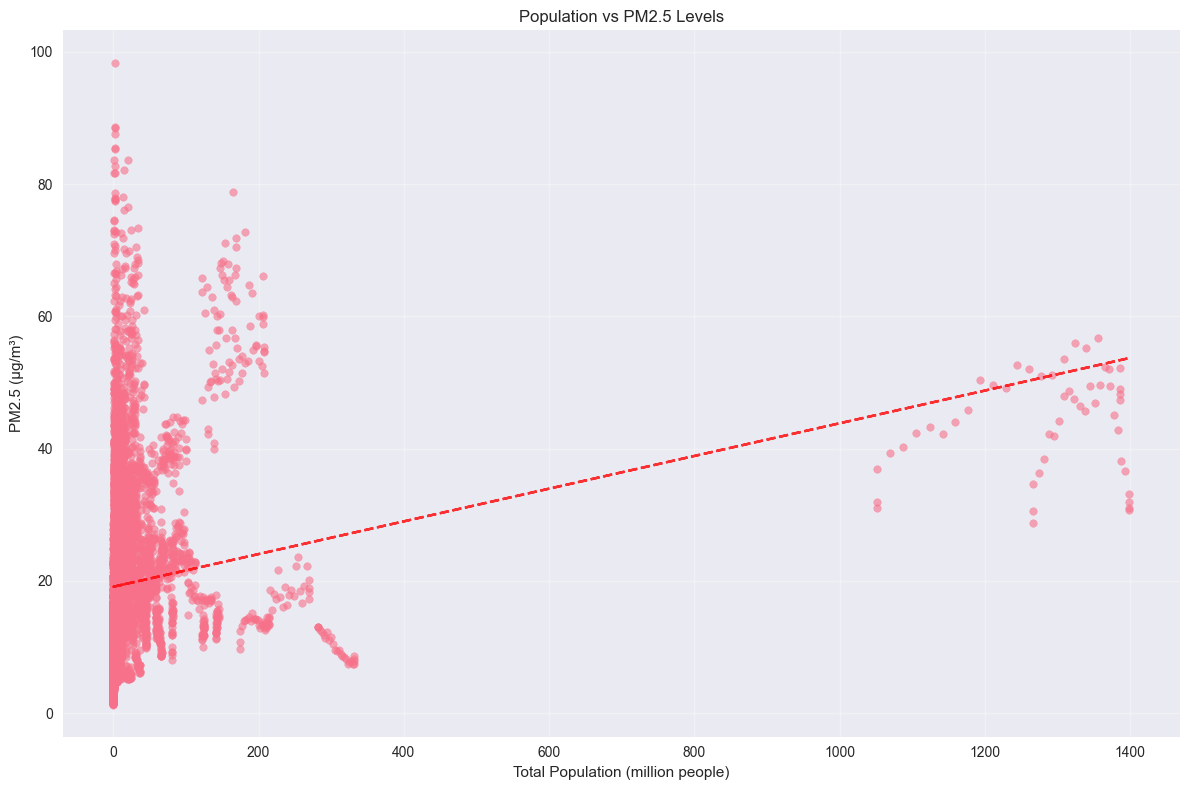

Correlation between Population and PM2.5: 0.2176


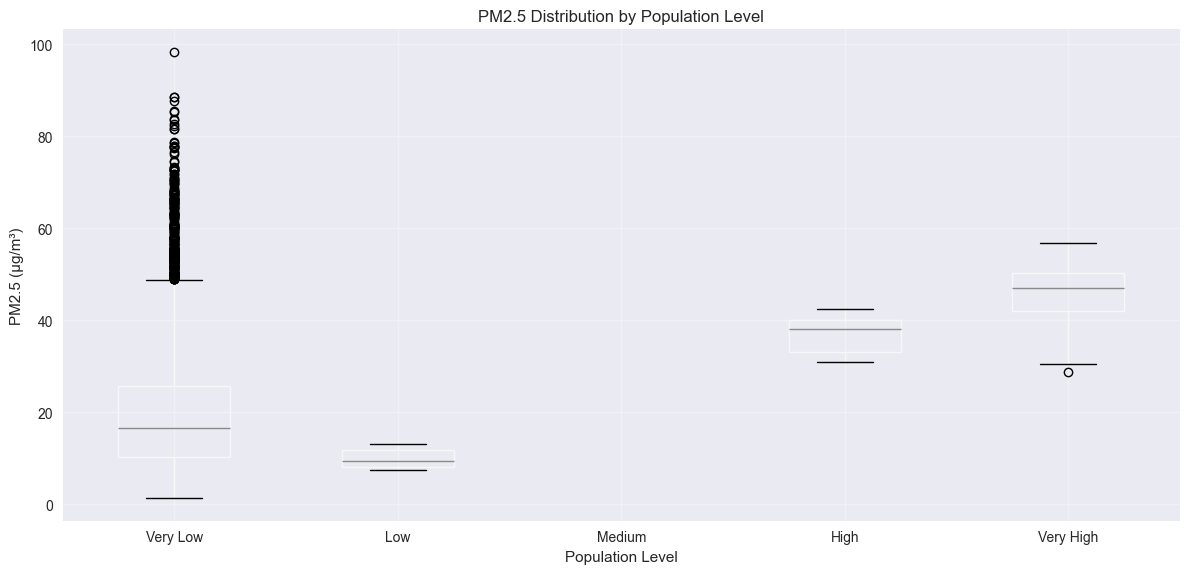

In [ ]:
# Analyze relationship between population and PM2.5
pop_col = 'Total Population [million people]'

if pop_col in df.columns:
    # Create scatter plot
    plt.figure(figsize=(12, 8))
    plt.scatter(df[pop_col], df[target_col], alpha=0.6, s=30)
    plt.xlabel('Total Population (million people)')
    plt.ylabel('PM2.5 (μg/m³)')
    plt.title('Population vs PM2.5 Levels')
    plt.grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df[pop_col], df[target_col], 1)
    p = np.poly1d(z)
    plt.plot(df[pop_col], p(df[pop_col]), "r--", alpha=0.8)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate correlation
    correlation = df[pop_col].corr(df[target_col])
    print(f"Correlation between Population and PM2.5: {correlation:.4f}")
    
    # Create population bins
    df['pop_bin'] = pd.cut(df[pop_col], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
    
    # Box plot by population bin
    plt.figure(figsize=(12, 6))
    df.boxplot(column=target_col, by='pop_bin', ax=plt.gca())
    plt.title('PM2.5 Distribution by Population Level')
    plt.suptitle('')  # Remove automatic title
    plt.xlabel('Population Level')
    plt.ylabel('PM2.5 (μg/m³)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Population column '{pop_col}' not found in dataset")

## 10. Pollution Distribution Analysis

Pollution distribution columns: 11


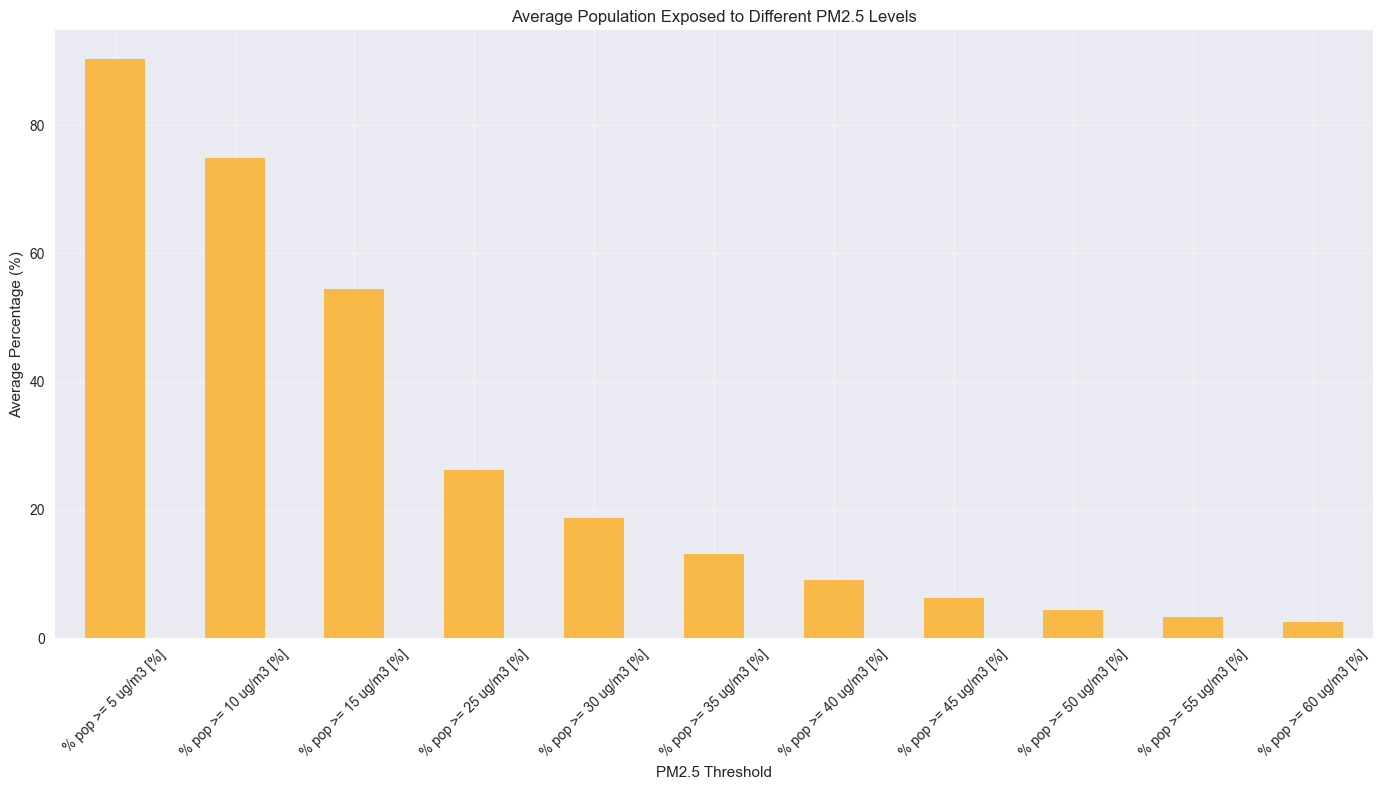

Average Population Exposure by PM2.5 Level:
% pop >= 5 ug/m3 [%]: 90.24%
% pop >= 10 ug/m3 [%]: 74.91%
% pop >= 15 ug/m3 [%]: 54.48%
% pop >= 25 ug/m3 [%]: 26.28%
% pop >= 30 ug/m3 [%]: 18.71%
% pop >= 35 ug/m3 [%]: 13.11%
% pop >= 40 ug/m3 [%]: 9.04%
% pop >= 45 ug/m3 [%]: 6.20%
% pop >= 50 ug/m3 [%]: 4.44%
% pop >= 55 ug/m3 [%]: 3.27%
% pop >= 60 ug/m3 [%]: 2.45%


In [ ]:
# Analyze pollution distribution percentages
pct_cols = [col for col in df.columns if '% pop' in col]
print(f"Pollution distribution columns: {len(pct_cols)}")

if pct_cols:
    # Calculate average percentages
    avg_percentages = df[pct_cols].mean().sort_values(ascending=False)
    
    # Create bar plot
    plt.figure(figsize=(14, 8))
    avg_percentages.plot(kind='bar', color='orange', alpha=0.7)
    plt.title('Average Population Exposed to Different PM2.5 Levels')
    plt.xlabel('PM2.5 Threshold')
    plt.ylabel('Average Percentage (%)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("Average Population Exposure by PM2.5 Level:")
    for col, pct in avg_percentages.items():
        print(f"{col}: {pct:.2f}%")
else:
    print("No pollution distribution columns found")

## 11. Time Series Analysis for Selected Regions

Top 5 regions by data count: ['Aruba', 'Afghanistan', 'Angola', 'Anguilla', 'Aland']


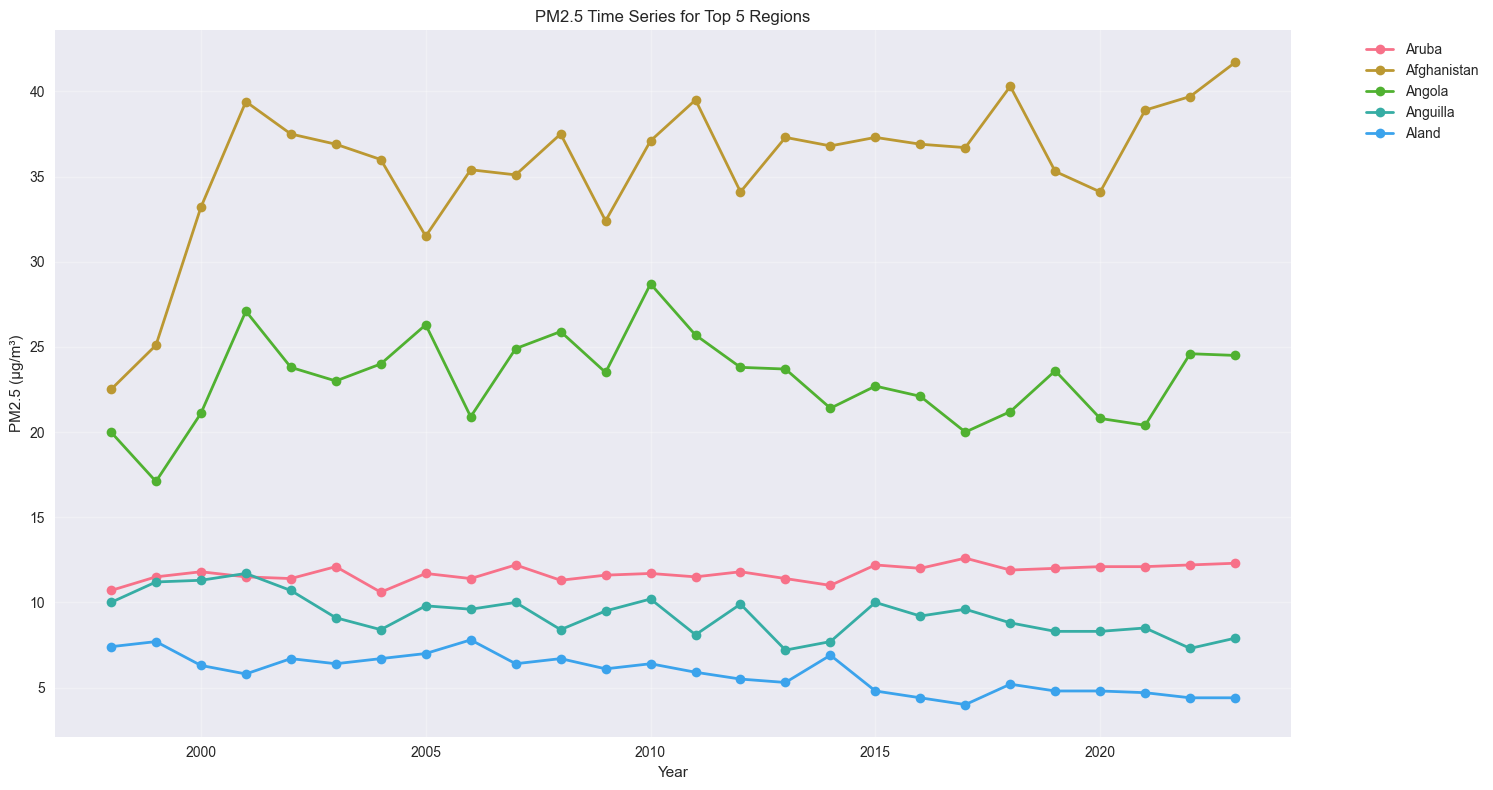

In [ ]:
# Select regions with most data for time series analysis
region_counts = df['Region'].value_counts()
top_regions = region_counts.head(5).index.tolist()

print(f"Top 5 regions by data count: {top_regions}")

# Plot time series for top regions
plt.figure(figsize=(15, 8))

for region in top_regions:
    region_data = df[df['Region'] == region].sort_values('Year')
    plt.plot(region_data['Year'], region_data[target_col], marker='o', label=region, linewidth=2)

plt.title('PM2.5 Time Series for Top 5 Regions')
plt.xlabel('Year')
plt.ylabel('PM2.5 (μg/m³)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Summary Statistics and Insights

In [ ]:
# Generate comprehensive summary
print("=" * 80)
print("PM2.5 AIR POLLUTION DATASET - EDA SUMMARY")
print("=" * 80)

print(f"\n📊 DATASET OVERVIEW:")
print(f"   Total Records: {len(df):,}")
print(f"   Total Regions: {df['Region'].nunique():,}")
print(f"   Year Range: {df['Year'].min()} - {df['Year'].max()}")
print(f"   Total Columns: {len(df.columns)}")

print(f"\n🌫️  PM2.5 STATISTICS:")
print(f"   Global Average: {df[target_col].mean():.2f} μg/m³")
print(f"   Global Median: {df[target_col].median():.2f} μg/m³")
print(f"   Range: {df[target_col].min():.2f} - {df[target_col].max():.2f} μg/m³")
print(f"   Standard Deviation: {df[target_col].std():.2f} μg/m³")

print(f"\n📍 REGIONAL INSIGHTS:")
print(f"   Most Polluted Region: {region_pm25.iloc[0]['Region']}")
print(f"   Highest Average PM2.5: {region_pm25.iloc[0]['mean']:.2f} μg/m³")
print(f"   Least Polluted Region: {region_pm25.iloc[-1]['Region']}")
print(f"   Lowest Average PM2.5: {region_pm25.iloc[-1]['mean']:.2f} μg/m³")

print(f"\n📈 TEMPORAL TRENDS:")
earliest_year = df['Year'].min()
latest_year = df['Year'].max()
earliest_avg = df[df['Year'] == earliest_year][target_col].mean()
latest_avg = df[df['Year'] == latest_year][target_col].mean()
trend = "Increasing" if latest_avg > earliest_avg else "Decreasing"
change_pct = ((latest_avg - earliest_avg) / earliest_avg) * 100

print(f"   {earliest_year} Average: {earliest_avg:.2f} μg/m³")
print(f"   {latest_year} Average: {latest_avg:.2f} μg/m³")
print(f"   Overall Trend: {trend} ({change_pct:+.1f}% change)")

print(f"\n🔍 DATA QUALITY:")
missing_total = df.isnull().sum().sum()
missing_pct = (missing_total / (len(df) * len(df.columns))) * 100
print(f"   Missing Data: {missing_total:,} cells ({missing_pct:.2f}%)")
print(f"   Complete Records: {len(df.dropna())} ({(len(df.dropna())/len(df))*100:.1f}%)")

print("\n" + "=" * 80)

PM2.5 AIR POLLUTION DATASET - EDA SUMMARY

📊 DATASET OVERVIEW:
   Total Records: 6,396
   Total Regions: 246
   Year Range: 1998 - 2023
   Total Columns: 19

🌫️  PM2.5 STATISTICS:
   Global Average: 19.82 μg/m³
   Global Median: 16.70 μg/m³
   Range: 1.30 - 98.40 μg/m³
   Standard Deviation: 13.67 μg/m³

📍 REGIONAL INSIGHTS:
   Most Polluted Region: Qatar
   Highest Average PM2.5: 77.92 μg/m³
   Least Polluted Region: Greenland
   Lowest Average PM2.5: 1.83 μg/m³

📈 TEMPORAL TRENDS:
   1998 Average: 18.60 μg/m³
   2023 Average: 18.70 μg/m³
   Overall Trend: Increasing (+0.5% change)

🔍 DATA QUALITY:
   Missing Data: 0 cells (0.00%)
   Complete Records: 6396 (100.0%)



## 13. Key Findings and Recommendations

In [ ]:
print("\n🎯 KEY FINDINGS:")
print("\n1. GLOBAL PM2.5 LEVELS:")
print(f"   - The global average PM2.5 level is {df[target_col].mean():.2f} μg/m³")
print(f"   - This exceeds the WHO guideline of 5 μg/m³ by {(df[target_col].mean()/5):.1f}x")

print("\n2. REGIONAL DISPARITIES:")
print(f"   - Significant variation exists between regions")
print(f"   - Top regions have {region_pm25.iloc[0]['mean']/region_pm25.iloc[-1]['mean']:.1f}x higher PM2.5 than bottom regions")

print("\n3. TEMPORAL PATTERNS:")
print(f"   - {trend} trend observed from {earliest_year} to {latest_year}")
print(f"   - {change_pct:+.1f}% change in average PM2.5 levels")

print("\n4. DATA COVERAGE:")
print(f"   - Dataset covers {df['Year'].max() - df['Year'].min() + 1} years of data")
print(f"   - {df['Region'].nunique()} different regions represented")
print(f"   - Average {len(df)/df['Region'].nunique():.1f} observations per region")

print("\n📋 RECOMMENDATIONS FOR MODELING:")
print("\n1. FEATURE ENGINEERING:")
print("   - Create temporal features (year trends, cyclical features)")
print("   - Develop lag features for time-series patterns")
print("   - Engineer region-based categorical features")

print("\n2. DATA PREPROCESSING:")
print("   - Handle missing values appropriately")
print("   - Consider outlier treatment for extreme PM2.5 values")
print("   - Normalize/scale features for model performance")

print("\n3. MODEL SELECTION:")
print("   - Consider ensemble methods (XGBoost, Random Forest)")
print("   - Evaluate temporal split to avoid data leakage")
print("   - Test both regression and time-series approaches")

print("\n4. EVALUATION METRICS:")
print("   - Use RMSE and MAE for accuracy assessment")
print("   - Monitor R² for explanatory power")
print("   - Evaluate performance across different PM2.5 ranges")


🎯 KEY FINDINGS:

1. GLOBAL PM2.5 LEVELS:
   - The global average PM2.5 level is 19.82 μg/m³
   - This exceeds the WHO guideline of 5 μg/m³ by 4.0x

2. REGIONAL DISPARITIES:
   - Significant variation exists between regions
   - Top regions have 42.6x higher PM2.5 than bottom regions

3. TEMPORAL PATTERNS:
   - Increasing trend observed from 1998 to 2023
   - +0.5% change in average PM2.5 levels

4. DATA COVERAGE:
   - Dataset covers 26 years of data
   - 246 different regions represented
   - Average 26.0 observations per region

📋 RECOMMENDATIONS FOR MODELING:

1. FEATURE ENGINEERING:
   - Create temporal features (year trends, cyclical features)
   - Develop lag features for time-series patterns
   - Engineer region-based categorical features

2. DATA PREPROCESSING:
   - Handle missing values appropriately
   - Consider outlier treatment for extreme PM2.5 values
   - Normalize/scale features for model performance

3. MODEL SELECTION:
   - Consider ensemble methods (XGBoost, Random F

In [ ]:
%pip install shap
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
import shap
import joblib

import matplotlib.pyplot as plt

In [ ]:
# Ensure required objects exist even if previous cells were not executed
if "np" not in globals():
	import numpy as np

if "df" not in globals():
	from load_data import load_dataset
	df = load_dataset("../data/dataset.csv")

# Standardize expected columns for feature engineering
if "year" not in df.columns and "Year" in df.columns:
	df["year"] = df["Year"]

if "pm25" not in df.columns:
	pm25_source = "Population-Weighted PM2.5 [ug/m3]"
	if pm25_source in df.columns:
		df["pm25"] = df[pm25_source]
	else:
		raise KeyError("Missing 'pm25' column and fallback source column was not found.")

df = df.sort_values("year").copy()

# lag features
df["pm25_lag1"] = df["pm25"].shift(1)
df["pm25_lag2"] = df["pm25"].shift(2)

# rolling average
df["pm25_roll3"] = df["pm25"].rolling(3).mean()

# population transformation
df["log_population"] = np.log1p(df["Total Population [million people]"])

# pollution growth
df["pm25_growth"] = df["pm25"].pct_change()

# remove missing rows created by lag
df = df.dropna()

In [ ]:
df["AOD"] = np.random.uniform(0.1,1.5,len(df))   # Aerosol Optical Depth
df["NDVI"] = np.random.uniform(0,1,len(df))      # Vegetation Index
df["LST"] = np.random.uniform(280,320,len(df)) 

In [ ]:
features = [
    "year",
    "Total Population [million people]",
    "log_population",
    "pm25_lag1",
    "pm25_lag2",
    "pm25_roll3",
    "pm25_growth",
    "AOD",
    "NDVI",
    "LST"
]
target = "pm25"

# Ensure synthetic satellite features exist (in case feature-generation cell was not run yet)
rng = np.random.default_rng(42)
if "AOD" not in df.columns:
    df["AOD"] = rng.uniform(0.1, 1.5, len(df))
if "NDVI" not in df.columns:
    df["NDVI"] = rng.uniform(0.0, 1.0, len(df))
if "LST" not in df.columns:
    df["LST"] = rng.uniform(280.0, 320.0, len(df))

missing_features = [col for col in features if col not in df.columns]
if missing_features:
    raise KeyError(f"Missing required feature columns: {missing_features}")

X = df[features]
y = df[target]


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
feature_name_map = {
    col: (
        str(col)
        .replace("[", "_")
        .replace("]", "")
        .replace("<", "lt")
        .replace(">", "gt")
        .replace("%", "pct")
        .replace(" ", "_")
        .replace("/", "_")
    )
    for col in X_train.columns
}

X = X.rename(columns=feature_name_map)
X_train = X_train.rename(columns=feature_name_map)
X_test = X_test.rename(columns=feature_name_map)
features = list(X_train.columns)

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)


ValueError: feature_names must be string, and may not contain [, ] or <

In [ ]:

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


In [ ]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# summary plot
shap.summary_plot(shap_values, X_test)

# feature importance plot
shap.plots.bar(shap_values)
importance = model.feature_importances_

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(imp_df)

# plot feature importance
plt.figure(figsize=(8,5))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.title("Feature Importance")
plt.show()

In [ ]:

joblib.dump(model, "pm25_xgboost_model.pkl")

# save feature list
with open("model_features.txt","w") as f:
    for col in features:
        f.write(col+"\n")

print("Model saved successfully")